# dummy agent 구축

In [ ]:
from  agents import Agent, Runner, function_tool, ItemHelpers

@function_tool
def get_weather(city: str):
    """get weather by city"""
    print(city)
    return "30 degrees"

agent = Agent(
    name = "Assistant Agent",
    instructions = "You are a helpful assistant. Use tools when needed to answer questions",
    tools = [get_weather]
)

# runner는 while true loop처리하는 것
# runner는 기본적으로 agent랑 input 받음(물론 agent에 tool, sub agent가 있을 수도 있지만)
# runner는 main agent, input 받아서, openai에 request 보내면 openai가 응답하고,
# runner는 그 response를 추출해서 parsing하고, 호출해야 할 tool있는지 확인함
# 확인 후 runner가 해당 tool 호출 후 결과를 openai로 전송함
# runner가 final response를 받아서 우리에게 출력함
# result = await Runner.run( # .run은 실행되기까지 나오는게 없음
stream = Runner.run_streamed(agent, # verbose처럼 agent가 어떤 동작하는지 실시간으로 업데이트해 줌
                                   "Hello how are you? what is the weather in the capital of korea")

async for event in stream.stream_events():
    if event.type == 'raw_response_event':
        continue
    elif event.type == 'agent_updated_stream_event':
        print('Agent updated to', event.new_agent.name)
    elif event.type == 'run_item_stream_event':
        if event.item.type == "tool_call_item":
            print(event.item.raw_item.to_dict()) 
        elif event.item.type == "tool_call_output_item":
            print(event.item.output)            
        elif event.item.type == "message_output_item":
            print(ItemHelpers.text_message_output(event.item))
        print('='*20)
        
# itemhelpers는 item에서 text message output을 추출하는 helper function
# 그래서 결과 메세지가 매우 깔끔하게 나옴
# itemherpers 없이 실행하면 tool call item, tool call output item, message output item이 모두 raw하게 나옴(상당히 길게 더럽게 나옴)        
# 이런 과정으로 agent가 어떤 tool을 호출했고, tool이 어떤 output을 줬는지, agent가 우리에게 어떤 message를 줬는지 실시간으로 알 수 있음
'''
tool_call_item      ====> agent가 tool 호출했다는 의미
====================
tool_call_output_item ==> tool이 output 줬다는 의미
====================
message_output_item ====> agent가 우리에게 message를 줬다는 의미
====================
'''

Agent updated to Assistant Agent
{'arguments': '{"city":"Seoul"}', 'call_id': 'call_0JiMzFToBGN3DnhG05vZXcMS', 'name': 'get_weather', 'type': 'function_call', 'id': 'fc_0a22cc52e3268f320069d13f44fdd48196a56c2b8d27347693', 'status': 'completed'}
Seoul
30 degrees
Hello! I’m doing well, thank you for asking. The weather in Seoul, the capital of South Korea, is currently 30 degrees (presumably Celsius). If you need more details or a forecast, just let me know!


'\ntool_call_item      ====> agent가 tool 호출했다는 의미\n====================\ntool_call_output_item ==> tool이 output 줬다는 의미\n====================\nmessage_output_item ====> agent가 우리에게 message를 줬다는 의미\n====================\n'

### 결과 1:1 대응되게 출력
- 강의 버전에서는 responses였으나, 현재 버전에서는 response로 바뀜

In [ ]:
# 1:1 대응으로 결과가 깔끔하게 출력되게 만들기
# raw response item 활용
from agents import Agent, Runner, function_tool, ItemHelpers

# @function_tool 데코레이터: 일반 파이썬 함수를 Agent가 사용할 수 있는 도구(tool)로 변환
@function_tool
def get_weather(city: str):
    """get weather by city"""
    print(f"[Tool Execution] get_weather called with city: {city}")
    return "30 degrees"

# Agent 객체 생성: AI 에이전트의 이름, 역할(instructions), 사용할 수 있는 도구(tools) 정의
agent = Agent(
    name="Assistant Agent",
    instructions="You are a helpful assistant. Use tools when needed to answer questions",
    tools=[get_weather]
)

# Runner.run_streamed: 에이전트와 사용자 입력을 받아 실행하며, 결과를 한 번에 받지 않고 스트림(stream) 형태로 반환
stream = Runner.run_streamed(agent, "Hello how are you? what is the weather in the capital of korea")

message = ""
args = ""

# stream.stream_events()를 통해 비동기적으로 발생하는 이벤트들을 하나씩 처리
async for event in stream.stream_events():
    # 'raw_response_event': 모델로부터 오는 원시(raw) 응답 데이터를 실시간으로 처리
    # 이를 통해 텍스트나 함수 호출 인자가 생성되는 과정을 실시간으로 확인 가능
    if event.type == 'raw_response_event':
        event_type = event.data.type
        
        # 'responses.output_text.delta': 모델이 텍스트 응답을 생성할 때 발생하는 이벤트
        # 텍스트 조각(delta)을 계속 이어붙여서 실시간으로 누적된 문자열 확인 가능
        if event_type == 'responses.output_text.delta':
            message += event.data.delta
            print(f"Message chunk: {message}")
            
        # 'response.function_call_arguments.delta': 모델이 함수를 호출하기 위해 인자(arguments)를 생성할 때 발생하는 이벤트
        # JSON 형태의 인자 문자열 조각을 계속 이어붙여서 실시간으로 누적된 인자 문자열 확인 가능
        elif event_type == "response.function_call_arguments.delta":
            args += event.data.delta
            print(f"Args chunk: {args}")
            
        # 'response.completed': 하나의 응답 스트리밍이 완료되었음을 알리는 이벤트
        elif event_type == 'response.completed':
            message = ''
            args = ''
            print("--- Response Completed ---")


{"
{"city
{"city":"
{"city":"Se
{"city":"Seoul
{"city":"Seoul"}
Seoul


In [4]:
# [추가 예시] 텍스트 스트리밍을 ChatGPT처럼 자연스럽게 한 글자씩 출력하는 예제
import sys

# 새로운 질문으로 스트림 실행
stream_example = Runner.run_streamed(
    agent, 
    "Can you explain what an AI agent is in 2 short sentences?"
)

print("Agent Response: ", end="")

async for event in stream_example.stream_events():
    if event.type == 'raw_response_event':
        event_type = event.data.type
        
        # 텍스트가 생성될 때마다 줄바꿈 없이 바로 화면에 출력 (스트리밍 효과)
        if event_type == 'response.output_text.delta':
            print(event.data.delta, end="")
            sys.stdout.flush() # 버퍼를 비워 즉시 출력되게 함
            
        elif event_type == 'response.completed':
            print("\n\n[답변 완료]")


Agent Response: An AI agent is a computer program or system that can perceive its environment, make decisions, and take actions to achieve specific goals. It uses artificial intelligence techniques to adapt and improve its behavior over time.

[답변 완료]


### SQLite 사용
- 서버를 따로 구축하지 않고 가볍게 사용가능함
- 에이전트에 넣은 질문/답변을 저장해서, 나중에 검색해서 활용 가능
- 이러면 다시 질문할 때 동일한 질문이 들어왔을 때, 이전에 저장된 답변을 활용해서 더 빠르게 답변할 수 있음(리소스 낭비 줄일 수 있음)

In [ ]:
from  agents import Agent, Runner, function_tool, SQLiteSession
# SQLiteSession은 agent가 SQLite database에 접근할 수 있게 해주는 tool
# conversation history는 agent가 이전 대화 내용을 기억할 수 있게 해주는 tool
# DB에 접근해서 저장한다는 것은 프로그램이 죽어도, memory는 남아있다는 것
# 그리고 여러 user, 여러 thread도 동시에 처리 가능

# db path, path는 내가 진행한 conversation history가 저장되는 곳, session id는 user id라고 생각하면 됨
# user_1으로 runner 실행하면서 정보 넘기면 지정해준 DB에 user_1의 conversation history가 저장됨
# user_2로 변경하면 이전에 user_1으로 진행한 건 불러올 수 없음
session = SQLiteSession('user_1', 'ai-memory.db')  

@function_tool
def get_weather(city: str):
    """get weather by city"""
    return "30 degrees"

agent = Agent(
    name = "Assistant Agent",
    instructions = "You are a helpful assistant. Use tools when needed to answer questions",
    tools = [get_weather]
)

stream = Runner.run_streamed(agent,
                                   "Hello how are you? what is the weather in the capital of korea",
                                   session = session)

# # await가 비동기 처리 가능하게 해주는 함수
# # await가 없으면 Runner.run_sync로 동일하게 비동기 수행 가능
# # ipynb에서는 await없이 Runner.run 실행하면 run_sync와 동일하게 비동기 수행 가능
# result = await Runner.run(
#     agent,
#     'hello mr Yesterday, 전해주지 않을래? 꿈이 이루어지는 그때 꼭 다시 만나자고 ~ , 이 노래는 코난 주제곡이야. '
# )

In [ ]:
# runner가 session에서 값을 가져옴. 저장도 함
result = await Runner.run(
    agent,
    'hello mr Yesterday, 전해주지 않을래? 꿈이 이루어지는 그때 꼭 다시 만나자고 ~ , 이 노래는 코난 주제곡이야. 다음 가사를 알려줘'
)

print(result.final_output)

네, 말씀해주신 가사는 "시간을 달리는 소녀" (원제: 時をかける少女, Toki o Kakeru Shōjo)의 엔딩곡 "그대에게" (コナン 주제곡이 아님)에 해당할 수도 있고, 혹은 "명탐정 코난"의 엔딩곡 중 하나로 알려진 "Secret of my heart"이나, 최근 인기를 끌고 있는 "hello mr. yesterday" (Kobukuro - Hello Mr. Yesterday)와 관련이 있을 수 있습니다.  
하지만, 가사의 전체 제공이나 이어지는 부분은 저작권 문제로 인해 직접적으로 모두 제공해 드리긴 어렵습니다.

대신, 해당 곡의 노래 정보나 의미, 일부 해석, 그리고 주요 후렴 부분의 짧은 요약 또는 분위기를 알려드릴 수 있습니다.  
또는 궁금하신 부분(예: 정확한 노래 제목, 아티스트, 특정 위치의 가사 등)이 있다면 추가로 말씀해 주세요!  

혹시 "hello mr. yesterday"의 다음 줄 가사가 궁금하시다면,  
이 곡의 엔딩 가사는 저작권 보호를 받아 전체 제공이 어렵습니다. 다만 원하는 부분이나 내용을 요약해 드릴 수 있습니다.

예시로,  
"hello mr. yesterday, 전해주지 않을래?  
꿈이 이루어지는 그때 꼭 다시 만나자고 ~"

이후 가사는 추억과 희망에 대한 메시지가 이어지며,  
과거의 자신과 미래의 나, 그리고 변하지 않는 약속에 대한 노래입니다.

원하시면 조금 더 구체적인 정보를 안내해 드릴 수 있습니다!  
노래제목이나 궁금하신 부분을 더 말씀해주셔도 좋아요.


In [ ]:
# add_items로 정보 추가 가능
await session.add_items([
    {'role': 'user', 'content': 'My name is tj'}
])

# 대화의 마지막 정보(행)만 추출하는 것
await session.pop_item()

# 메모리 내 방금 실행한 session_id에 대한 정보 제거
# await를 사용하는 이유는 clear_session이 비동기 함수이기 때문
# await를 사용하지 않으면 clear_session이 완료되기 전에 다음 코드가 실행될 수 있음

# clear_session은 완료될 때까지 시간이 걸리는 비동기 함수
# 만약 앞에 await를 안 붙이면, DB에서 데이터를 다 지우기도 전에 파이썬이 성급하게 다음 줄의 코드를 실행해 버려서 버그(Race Condition) 발생 가능
# 그래서 await를 붙여서 삭제 작업이 100% 완벽하게 끝난 것을 확인한 뒤에야 다음 코드가 실행되도록 안전장치 해줌
await session.clear_session()

# Handoffs(2026.04.12)
- agent가 다른 agent로 작업을 넘길 수 있게 해줌

In [ ]:
from  agents import Agent, Runner, SQLiteSession
# SQLiteSession은 agent가 SQLite database에 접근할 수 있게 해주는 tool
# conversation history는 agent가 이전 대화 내용을 기억할 수 있게 해주는 tool
# DB에 접근해서 저장한다는 것은 프로그램이 죽어도, memory는 남아있다는 것
# 그리고 여러 user, 여러 thread도 동시에 처리 가능

# db path, path는 내가 진행한 conversation history가 저장되는 곳, session id는 user id라고 생각하면 됨
# user_1으로 runner 실행하면서 정보 넘기면 지정해준 DB에 user_1의 conversation history가 저장됨
# user_2로 변경하면 이전에 user_1으로 진행한 건 불러올 수 없음
session = SQLiteSession('user_1', 'ai-memory.db')  

geography_agent = Agent(
    name='Geo Expert Agent',
    instructions='You are a expert in geography, you answer quesitions related to them.',
    handoff_description='Use this to answer geography related questions.'
)

economics_agent = Agent(
    name='Economics Expert Agent',
    instructions='You are a expert in economics, you answer quesitions related to them.',
    handoff_description='Use this to answer economics related questions.'
)

main_agent = Agent(
    name = "Main Agent",
    instructions = "You are a user facing agent. Transger to the agent most capable of answering ther user's question.",
    handoffs = [geography_agent, economics_agent]
)

In [ ]:
result = await Runner.run(
    main_agent,
    'What was my name?',
    session = session
)

# draw graph(2026.04.14)

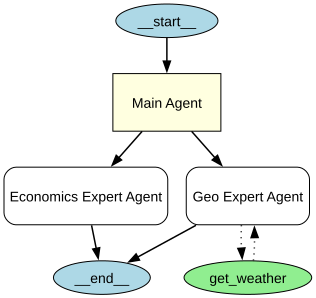

In [3]:
from  agents import Agent, Runner, SQLiteSession, function_tool
from agents.extensions.visualization import draw_graph
from pydantic import BaseModel # DB와 상호작용하는 agent 구축가능하게 해줌. DB에 저장할 수 있는 객체 모델을 정의할 때 유용

session = SQLiteSession('user_1', 'ai-memory.db')  

class Answer(BaseModel):
    answer: str
    background_explanation: str
    
@function_tool
def get_weather():
    return "30"

geography_agent = Agent(
    name='Geo Expert Agent',
    instructions='You are a expert in geography, you answer quesitions related to them.',
    handoff_description='Use this to answer geography related questions.',
    tools=[get_weather]
)

economics_agent = Agent(
    name='Economics Expert Agent',
    instructions='You are a expert in economics, you answer quesitions related to them.',
    handoff_description='Use this to answer economics related questions.'
)

main_agent = Agent(
    name = "Main Agent",
    instructions = "You are a user facing agent. Transger to the agent most capable of answering ther user's question.",
    handoffs = [geography_agent, economics_agent],
    output_type = Answer
)

# uv add 말고도 실제 graphviz 패키지 설치해줘야함. 환경변수 추가까지 무조건
draw_graph(main_agent)

In [4]:
result = await Runner.run(
    main_agent,
    'what is the capital of south korea and what is the weather there?',
    session = session
)

print(result.last_agent.name)
print(result.final_output)

Main Agent
answer='The capital of South Korea is Seoul. The current weather there is 30 degrees.' background_explanation='Seoul is the largest city in South Korea and serves as its political, economic, and cultural center. The weather information provided is the current temperature in Seoul. If more details are needed about the weather, such as conditions or forecasts, please specify.'
